In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')

In [9]:
df = pd.read_csv('processed_data.csv')

X = df.drop(['Stars Count'], axis='columns')
y = df['Stars Count']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=13
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (2049, 101)
Test shape: (513, 101)


In [10]:
tree_model = DecisionTreeRegressor(random_state=13)
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

baseline_metrics = {
    'MAE_log': mean_absolute_error(y_test, y_pred),
    'RMSE_log': np.sqrt(mean_squared_error(y_test, y_pred)),
    'R2_log': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test_original, y_pred_original),
    'RMSE': np.sqrt(mean_squared_error(y_test_original, y_pred_original)),
}

pd.DataFrame([baseline_metrics], index=['Decision Tree baseline'])

,MAE_log,RMSE_log,R2_log,MAE,RMSE
Decision Tree baseline,0.448916,0.619495,0.781021,9985.604288,26184.917333


In [11]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20, 30, 50, 100],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=13),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV score:', -grid_search.best_score_)

Best params: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 50}
Best CV score: 0.5411001834646618


In [12]:
best_tree = grid_search.best_estimator_
y_pred_best = best_tree.predict(X_test)


y_test_original = np.expm1(y_test)
y_pred_best_original = np.expm1(y_pred_best)

tuned_metrics = {
    'MAE_log': mean_absolute_error(y_test, y_pred_best),
    'RMSE_log': np.sqrt(mean_squared_error(y_test, y_pred_best)),
    'R2_log': r2_score(y_test, y_pred_best),
    'MAE': mean_absolute_error(y_test_original, y_pred_best_original),
    'RMSE': np.sqrt(mean_squared_error(y_test_original, y_pred_best_original)),
}

pd.DataFrame([
    baseline_metrics,
    tuned_metrics
], index=['Decision Tree baseline', 'Decision Tree tuned'])

,MAE_log,RMSE_log,R2_log,MAE,RMSE
Decision Tree baseline,0.448916,0.619495,0.781021,9985.604288,26184.917333
Decision Tree tuned,0.369341,0.512249,0.850277,8207.478612,23822.706260


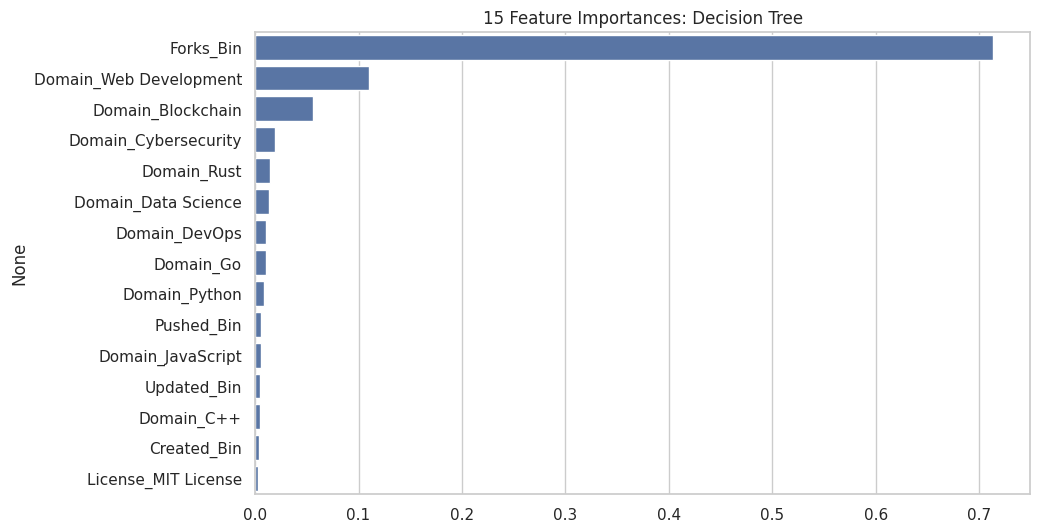

In [13]:
feature_importance = pd.Series(best_tree.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('15 Feature Importances: Decision Tree')
plt.show()

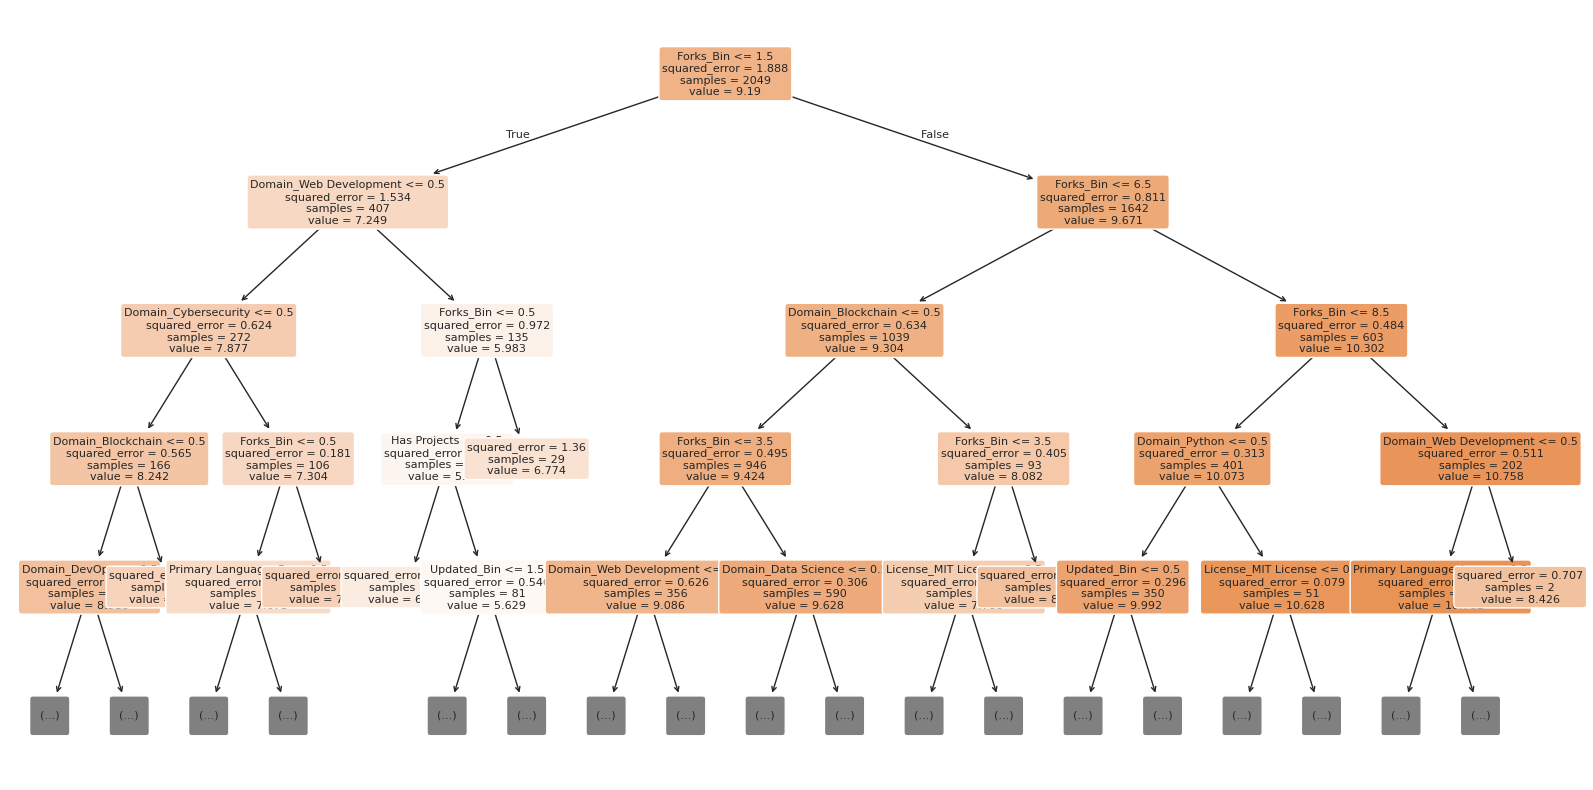

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    best_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4 # Больше - не читаемо 
)
plt.show()